In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [3]:
import warnings
from abc import ABC, abstractmethod
from random import betavariate
from typing import Any, List, Literal, Optional, Tuple, Union, Dict

import numpy as np
import pymc.math as pmath
from numpy import array, c_, insert, mean, multiply, ones, sqrt, std
from numpy.typing import ArrayLike
from pymc import Bernoulli, Data, Deterministic, fit, sample
from pymc import Model as PymcModel
from pymc import StudentT as PymcStudentT
import pymc as pm
from pytensor.tensor import TensorVariable, dot
from scipy.stats import t

from pybandits.base import BinaryReward, Probability, PyBanditsBaseModel
from pybandits.pydantic_version_compatibility import (
    PYDANTIC_VERSION_1,
    PYDANTIC_VERSION_2,
    Field,
    NonNegativeFloat,
    PositiveInt,
    confloat,
    model_validator,
    pydantic_version,
    validate_call,
)

UpdateMethods = Literal["MCMC", "VI"]



WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [51]:
class BayesianLogisticRegression:
    def __init__(self, in_dim, mu=0, sigma=10.):
        self.update_method = "VI" # "MCMC"

        self.in_dim = in_dim

        self.init_params(mu, sigma)
        self.init_model()

    def init_params(self, mu, sigma):

        self.shape_dict = {
            "w1": dict(shape=(self.in_dim)),
            "b1": dict(shape=(1)),
        }

        self.posterior_params = {name: dict(mu=mu, sigma=sigma) for name in self.shape_dict.keys()}

    def init_model(self):
        self.trace = None
        self.approx = None
        self.is_fitted = False

        x = np.zeros((1, self.in_dim))  # dummy data
        y = np.zeros(1)  # dummy data

        self.evaluate_model(x, y)

    def mcmc_sample(self, x, draws=1000, tune=500):
        _default_mcmc_kwargs = dict(
        tune=500,
        draws=1000,
        chains=2,
        init="adapt_diag",
        cores=1,
        target_accept=0.95,
        progressbar=False,
        return_inferencedata=False,
    )
        y = np.zeros(len(x))
        with self.model:
            pm.set_data(new_data={"ann_input": x, "ann_output": y})
            trace = pm.sample(**_default_mcmc_kwargs)
        return trace

    def evaluate_model(self, x, y):
        params_dict = {}
        with pm.Model() as self.model:
            # Define data variables using minibatches
            ann_input = pm.MutableData("ann_input", x)
            ann_output = pm.MutableData("ann_output", y)

            for name in self.shape_dict.keys():
                params_dict[name] = pm.Normal(name=name, **self.posterior_params[name], **self.shape_dict[name])

            # Build neural-network using tanh activation function
            act_out = pm.Deterministic("act_out",pm.math.dot(ann_input, params_dict["w1"]) + params_dict["b1"])
            # act_out = pm.Deterministic("act_out", pm.math.dot(act_1, params_dict["w2"]) + params_dict["b2"])
            # Binary classification -> Bernoulli likelihood
            out = pm.Normal(
                "out",
                mu=act_out,
                sigma = 0.001,
                observed=ann_output
            )

    def update(self, x_train, y_train, num_iter=1000, learning_rate=0.01):

        with self.model:
            pm.set_data(new_data={"ann_input": x_train, "ann_output": y_train})
            self.approx = pm.fit(n=num_iter, method='advi', obj_optimizer=pm.adam(learning_rate=learning_rate))
        self.is_fitted = True
        trace = self.approx.sample(draws=500)

        for name in self.posterior_params.keys():
            self.posterior_params[name]["mu"] = np.mean(trace['posterior'][name].squeeze(), axis=0).values
            self.posterior_params[name]["sigma"] = np.std(trace['posterior'][name].squeeze(), axis=0).values

        self.evaluate_model(x_train, y_train)  # re-evaluate the _model with the new parameters
    
    def mcmc_update(self, x_train, y_train):
        _default_mcmc_kwargs = dict(
        tune=500,
        draws=1000,
        chains=2,
        init="adapt_diag",
        cores=1,
        target_accept=0.95,
        progressbar=False,
        return_inferencedata=False,
    )
        with self.model:
            pm.set_data(new_data={"ann_input": x_train, "ann_output": y_train})
            trace = pm.sample(**_default_mcmc_kwargs)

        for name in self.posterior_params.keys():
            self.posterior_params[name]["mu"] = np.mean(trace[name].squeeze(), axis=0)
            self.posterior_params[name]["sigma"] = np.std(trace[name].squeeze(), axis=0)

        self.evaluate_model(x_train, y_train)  # re-evaluate the _model with the new parameters


    def sample(self, x=None, draws=100):
        y = np.zeros(len(x))
        with self.model:
            pm.set_data(new_data={"ann_input": x, "ann_output": y})
            trace  = pm.sample_prior_predictive(samples=draws)

        return trace


    def summary(self):
        if self.trace is not None:
            return pm.summary(self.trace)
        elif self.approx is not None:
            return self.approx.summary()
        else:
            print("No trace or variational approximation available. Run the sample or fit_variational method first.")


In [5]:
class BayesianModel:
    def __init__(self, in_dim, hid_dim, mu=0, sigma=10.):
        self.update_method = "VI" # "MCMC"

        self.in_dim = in_dim
        self.hid_dim = hid_dim

        self.init_params(mu, sigma)
        self.init_model()

    def init_params(self, mu, sigma):

        self.shape_dict = {
            "w1": dict(shape=(self.in_dim, self.hid_dim)),
            "b1": dict(shape=(self.hid_dim)),
            "w2": dict(shape=(self.hid_dim)),
            "b2": dict(shape=(1))
        }

        self.posterior_params = {name: dict(mu=mu, sigma=sigma) for name in self.shape_dict.keys()}

    def init_model(self):
        self.trace = None
        self.approx = None
        self.is_fitted = False

        x = np.zeros((1, self.in_dim))  # dummy data
        y = np.zeros(1)  # dummy data

        self.evaluate_model(x, y)

    def mcmc_sample(self, draws=1000, tune=500):
        with self.model:
            self.trace = pm.sample(draws=draws, tune=tune)

    def evaluate_model(self, x, y):
        params_dict = {}
        with pm.Model() as self.model:
            # Define data variables using minibatches
            ann_input = pm.MutableData("ann_input", x)
            ann_output = pm.MutableData("ann_output", y)

            for name in self.shape_dict.keys():
                params_dict[name] = pm.Normal(name=name, **self.posterior_params[name], **self.shape_dict[name])

            # Build neural-network using tanh activation function
            act_1 = pm.math.tanh(pm.math.dot(ann_input, params_dict["w1"]) + params_dict["b1"])
            act_out = pm.Deterministic("act_out",pm.math.sigmoid(pm.math.dot(act_1, params_dict["w2"]) + params_dict["b2"]))
            # act_out = pm.Deterministic("act_out", pm.math.dot(act_1, params_dict["w2"]) + params_dict["b2"])
            # Binary classification -> Bernoulli likelihood
            out = pm.Bernoulli(
                "out",
                p=act_out,
                observed=ann_output
            )

    def update(self, x_train, y_train, num_iter=1000, learning_rate=0.01):

        with self.model:
            pm.set_data(new_data={"ann_input": x_train, "ann_output": y_train})
            self.approx = pm.fit(n=num_iter, method='advi', obj_optimizer=pm.adam(learning_rate=learning_rate))
        self.is_fitted = True
        trace = self.approx.sample(draws=500)

        for name in self.posterior_params.keys():
            self.posterior_params[name]["mu"] = np.mean(trace['posterior'][name].squeeze(), axis=0).values
            self.posterior_params[name]["sigma"] = np.std(trace['posterior'][name].squeeze(), axis=0).values

        self.evaluate_model(x_train, y_train)  # re-evaluate the _model with the new parameters

    def sample(self, x=None, draws=100):
        y = np.zeros(len(x))
        with self.model:
            pm.set_data(new_data={"ann_input": x, "ann_output": y})
            trace  = pm.sample_prior_predictive(samples=draws) # posterior are loaded to priors

        return trace



    def summary(self):
        if self.trace is not None:
            return pm.summary(self.trace)
        elif self.approx is not None:
            return self.approx.summary()
        else:
            print("No trace or variational approximation available. Run the sample or fit_variational method first.")


In [6]:
def get_simple_data_train():
    x = np.linspace(-.2, 0.2, 500)
    x = np.hstack([x, np.linspace(.6, 1, 500)])
    eps = 0.02 * np.random.randn(x.shape[0])
    y = x + 0.3 * np.sin(2 * np.pi * (x + eps)) + 0.3 * np.sin(4 * np.pi * (x + eps)) + eps
    x_train = torch.from_numpy(x).float()[:, None]
    y_train = torch.from_numpy(y).float()
    return x_train, y_train

In [35]:
x_train, y_train = get_simple_data_train()
x_true = np.linspace(-.5, 1.5, 1000)
y_true = x_true + 0.3 * np.sin(2 * np.pi * x_true) + 0.3 * np.sin(4 * np.pi * x_true)



In [8]:
def plot_generic(x_true, y_true, x_train,y_train, add_to_plot=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.xlim([-.5, 1.5])
    plt.ylim([-1.5, 2.5])
    plt.xlabel("X", fontsize=30)
    plt.ylabel("Y", fontsize=30)



    ax.plot(x_train, y_train, 'ko', markersize=4, label="observations")
    ax.plot(x_true, y_true, 'b-', linewidth=3, label="true function")
    if add_to_plot is not None:
        add_to_plot(ax)

    plt.legend(loc=4, fontsize=15, frameon=False)
    plt.show()

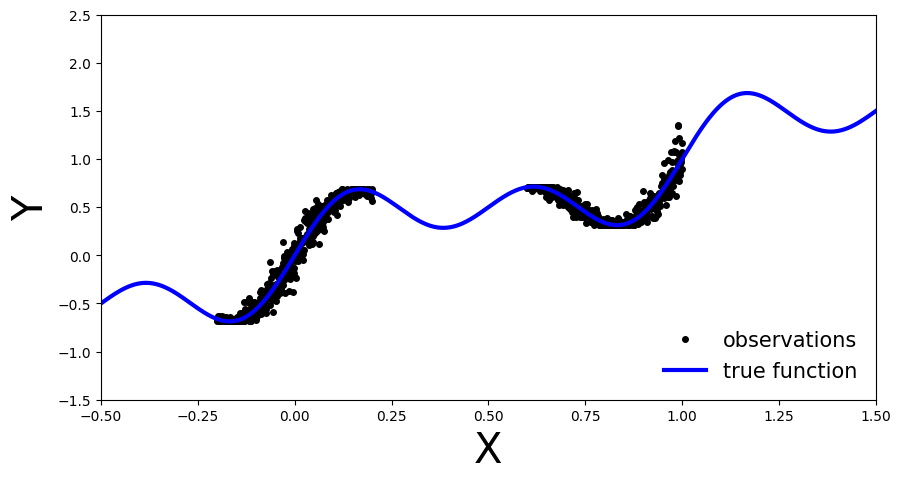

In [9]:
plot_generic(x_true, y_true , x_train,y_train)


In [52]:
lr_model = BayesianLogisticRegression(in_dim=1)

In [64]:

def plot_predictions(x_true, y_true, x_train, y_train, preds):
    y_pred = preds.mean(axis=1).squeeze()
    y_std = preds.std(axis=1).squeeze()

    fig, ax = plt.subplots(figsize=(10, 5))
    xlims = [-0.5, 1.5]
    ylims = [-1.5, 2.5]
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("X", fontsize=30)
    plt.ylabel("Y", fontsize=30)

    ax.plot(x_true, y_true, 'b-', linewidth=3, label="true function")
    ax.plot(x_train, y_train, 'ko', markersize=4, label="observations")
    ax.plot(x_train, y_train, 'ko', markersize=3)
    ax.plot(x_true, y_pred, '-', linewidth=3, color="#408765", label="predictive mean")
    ax.fill_between(x_true, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=5)

    plt.legend(loc=4, fontsize=15, frameon=False)
    return y_pred, y_std

## MCMC

In [54]:

lr_model.mcmc_update(x_train, y_train)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [w1, b1]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [55]:
trace = lr_model.mcmc_sample(x_train)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [w1, b1]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [56]:
trace = lr_model.sample(x_true.reshape(-1,1))

Sampling: [b1, out, w1]


In [57]:
trace['prior_predictive']["out"].shape

(1, 100, 1000)

In [58]:
preds_out = trace['prior_predictive']["out"]

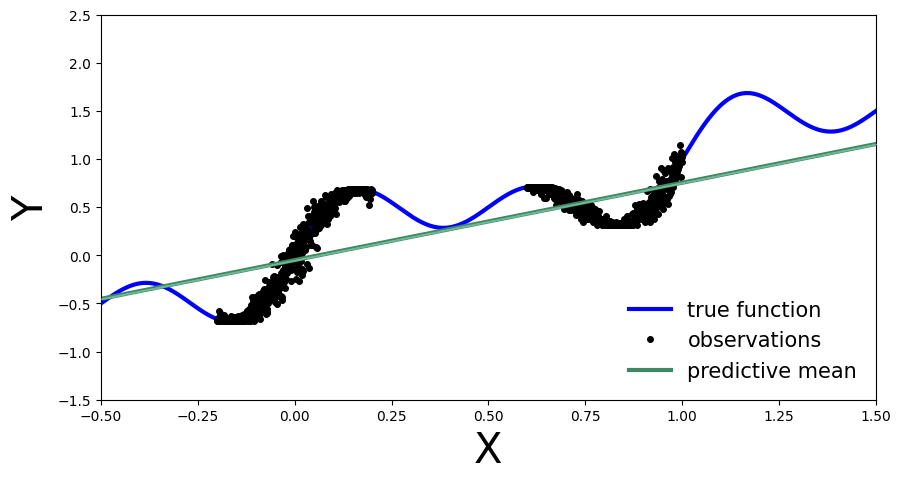

In [65]:
mean_, var_ = plot_predictions(x_true, y_true, x_train, y_train, preds_out)


In [74]:
np.var(trace['prior']['w1'].squeeze())

<xarray.DataArray 'w1' ()>
array(4.99365285e-09)
Coordinates:
    chain     int64 0
    w1_dim_0  int64 0

## VI

In [78]:
lr_model.update(x_train, y_train, num_iter=3000, learning_rate=0.01)

Finished [100%]: Average Loss = 4,642.8


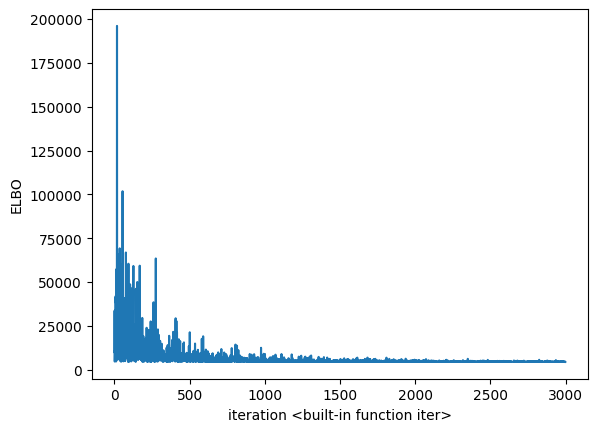

In [79]:
plt.figure()
plt.plot(lr_model.approx.hist)
plt.ylabel("ELBO")
plt.xlabel(f"iteration {iter}");
plt.show()

In [29]:
preds['prior_predictive']['out']

<xarray.DataArray 'out' (chain: 1, draw: 100, out_dim_0: 3000)>
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0]]])
Coordinates:
  * chain      (chain) int64 0
  * draw       (draw) int64 0 1 2 3 4 5 6 7 8 9 ... 91 92 93 94 95 96 97 98 99
  * out_dim_0  (out_dim_0) int64 0 1 2 3 4 5 6 ... 2994 2995 2996 2997 2998 2999

In [99]:

xlims = [-0.5, 1.5]
x_test = np.linspace(xlims[0], xlims[1], 3000).reshape(-1,1)
preds = lr_model.mcmc_sample(x_test)
preds_out  = preds['out'] 

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w1, b1]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 3 seconds.


KeyError: 'out'

In [75]:
x_test = x_test.squeeze()

ValueError: 'x' is not 1-dimensional

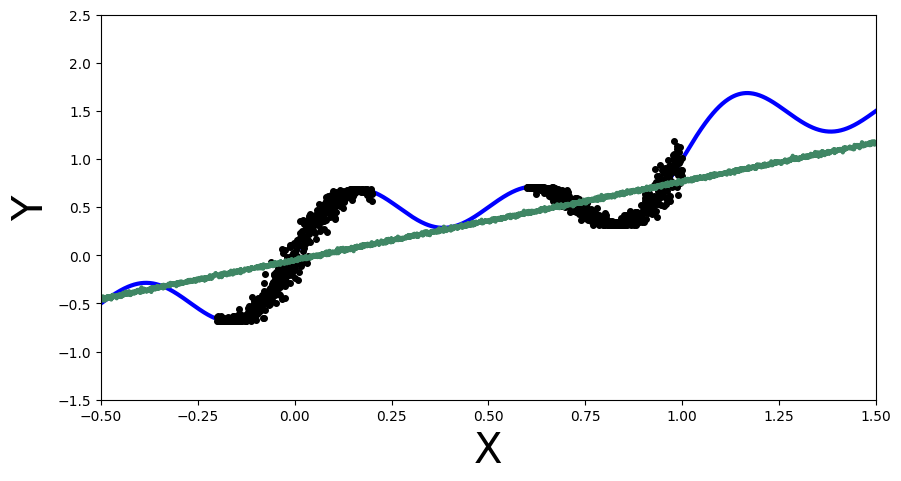

In [82]:
plot_predictions(x_true, y_true, x_train, y_train, preds_out)

## Bayesian Neural Network